# Simulating CBEDs with abTEM

In [1]:
import os
work_dir = "H:\workspace\\bott"
os.chdir(work_dir)
print("Current working dir: ", os.getcwd())

Current working dir:  H:\workspace\bott


## All the parameters are configured below

In [2]:
# Input unknown
thickness, tilt_x, tilt_y = 25, 2, -20 #(Ang, mrad, mrad)

# Setup abtem device
device_abtem = 'gpu'

# Read cif into abTEM for 4D-STEM generation
path_crystal = './data/SrTiO3.cif'

# Potential params
potential_extent_x = 62.6 # Ang
potential_extent_y = 62.6 # Ang
lateral_sampling = 0.2*2/3 # Ptycho recon pixel size = 0.2 Ang, so ptycho CBED need 1/2dx = 2.5 Ang-1 kMax. Considering the 2/3 kMax antialias, we need 2.5*1.5 = 3.75 Ang-1 for abTEM CBED or equivalently 0.1333 Ang px
vertical_sampling = 2
potential_parametrization = "lobato" # Seems to be more accurate then "kirkland"
potential_projection = "finite" # infinite is faster but less accurate

# Phonon params
random_seed = 42
use_frozen_phonon = False
num_phonon_configs = 5
phonon_sigma = {'Sr':.088,'Ti':.0746,'O':.0963} #0.1 # Ang 

# Probe params
energy = 200e3
convergence_angle = 19.1
df = 0
aberrations = {}

# Scan and pacbed
scan_step_size = 0.3
return_pacbed = True

## Everything below is just calculation

In [3]:
# Setup imports
from bott.utils import get_EM_constants

import ase
import abtem
import numpy as np
import dask

if device_abtem == 'gpu':
    import cupy as xp
    abtem.config.set({"dask.chunk-size-gpu" : "2048 MB"})
    dask.config.set({"num_workers": 1});
elif device_abtem == 'cpu':
    import numpy as xp
else:
    raise ValueError(f"device_abtem '{device_abtem}' not implemented yet, please use 'cpu', or 'gpu'!")

# abtem configure
abtem.config.set({"local_diagnostics.progress_bar": False});
abtem.config.set({"device": device_abtem});

import matplotlib.pyplot as plt

In [4]:
# Setup cell
unit_cell = ase.io.read(path_crystal)
target_object_extent = np.array((potential_extent_x, potential_extent_y, thickness)) # Specimen range in Ang (x,y,z)
cell_constants = np.diag(unit_cell.cell)
super_cell_reps = np.ceil(target_object_extent / cell_constants).astype('int')
super_cell = unit_cell * super_cell_reps
print(f"super_cell = {super_cell}")

super_cell = Atoms(symbols='O5376Sr1792Ti1792', pbc=True, cell=[62.60322096, 62.60322096, 27.38890917], spacegroup_kinds=...)


In [5]:
# Calculate the potential
if use_frozen_phonon:
    print(f"Using FrozenPhonons potential with {num_phonon_configs} configs")
    atoms = abtem.FrozenPhonons(atoms=super_cell, num_configs=num_phonon_configs, sigmas=phonon_sigma, seed=random_seed)
    potential = abtem.Potential(atoms=atoms, sampling=lateral_sampling, parametrization=potential_parametrization,
        slice_thickness=vertical_sampling, projection=potential_projection)
    # potential_arr = np.mean(potential.build().compute(progress_bar=False).array.get(), axis=0)
else:
    print("Using Static potential")
    potential = abtem.Potential(atoms=super_cell, sampling=lateral_sampling, parametrization=potential_parametrization,
        slice_thickness=vertical_sampling, projection=potential_projection)
    # potential_arr = potential.build().compute(progress_bar=False).array
    
print(f"potential.shape = {potential.shape}")

Using Static potential
potential.shape = (14, 470, 470)


In [6]:
# Calculate the probe
probe = abtem.Probe(energy=energy, semiangle_cutoff=convergence_angle, defocus=df, tilt=(tilt_x,tilt_y), **aberrations)
probe.grid.match(potential)

# Useful information
wavelength = get_EM_constants(energy/1e3, 'wavelength')
kmax_antialias = 1/lateral_sampling/3 # 1/Ang #The kmax_antialiasing = 2.675 Ang-1 
alpha_max_antialias = wavelength * kmax_antialias # rad
print(f"Energy = {energy/1e3} kV, rel. wavelength = {wavelength:.4f} Ang")
print(f"CBED collection kmax = {kmax_antialias:.4f} 1/Ang, collection alpha_max = {alpha_max_antialias*1000:.4f} mrad")
print(f"probe.shape = {probe.shape}")
print(f"probe.axes_metadata = {probe.axes_metadata}")

Energy = 200.0 kV, rel. wavelength = 0.0251 Ang
CBED collection kmax = 2.5000 1/Ang, collection alpha_max = 62.6984 mrad
probe.shape = (470, 470)
probe.axes_metadata = type           label    coordinates
-------------  -------  -------------------
RealSpaceAxis  x [Å]    0.00 0.13 ... 62.47
RealSpaceAxis  y [Å]    0.00 0.13 ... 62.47


In [7]:
# Make scan for 1 unit cell along x, y
potential_extent = np.array(potential.extent)
scan_start = np.array(potential_extent)/2
scan_end = scan_start + cell_constants[:2]
grid_scan = abtem.scan.GridScan(start=scan_start, end=scan_end,sampling=scan_step_size)
print(f"grid_scan.axes_metadata = {grid_scan.axes_metadata}")

grid_scan.axes_metadata = type      label    coordinates
--------  -------  ---------------------
ScanAxis  x [Å]    31.30 31.58 ... 34.93
ScanAxis  y [Å]    31.30 31.58 ... 34.93


In [8]:
# Get cbeds
cbeds = probe.multislice(scan = grid_scan, potential = potential).diffraction_patterns(max_angle='cutoff').reduce_ensemble().compute(progress_bar=False)
print(f"cbeds.axes_metadata = {cbeds.axes_metadata}")

if return_pacbed:
    measurement = xp.mean(cbeds.array, axis=(0,1))
else:
    measurement = cbeds.array

# Cast measurement into numpy array
if device_abtem == 'gpu':
    measurement = measurement.get()
print(f"\nmeasurement.shape = {measurement.shape}")

cbeds.axes_metadata = type                 label     coordinates
-------------------  --------  ---------------------
ScanAxis             x [Å]     31.30 31.58 ... 34.93
ScanAxis             y [Å]     31.30 31.58 ... 34.93
ReciprocalSpaceAxis  kx [1/Å]  -2.51 -2.49 ... 2.51
ReciprocalSpaceAxis  ky [1/Å]  -2.51 -2.49 ... 2.51

measurement.shape = (315, 315)


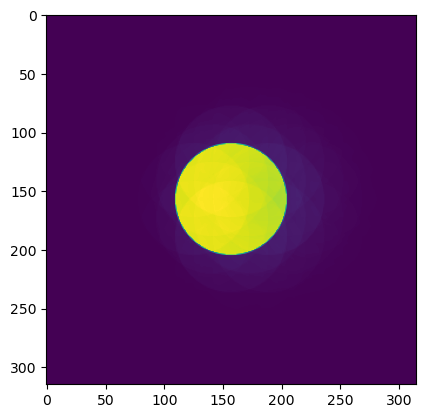

In [9]:
plt.figure()
plt.imshow(measurement)
plt.show()

## Try the function version

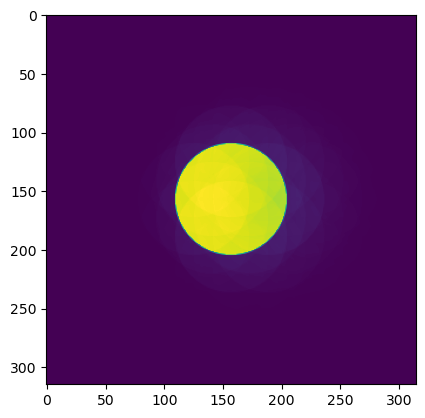

In [11]:
from bott.physics_models import simulate_cbed
measurement = simulate_cbed(thickness, tilt_x, tilt_y)

plt.figure()
plt.imshow(measurement)
plt.show()